# Análisis Exploratorio de Datos (EDA) — ACH Data · ACH Colombia

**Metodología:** CRISP-DM · Fases 1 (Entendimiento del negocio) y 2 (Entendimiento de los datos)
**Fuentes de datos:** `Data/` — 3 extractos ofuscados de las fuentes de ACH Colombia
**Documentación de contexto:** `Docs/` — contexto de la empresa, modelo metodológico y casos de uso

---

## 1 · Entendimiento del negocio (CRISP-DM · Fase 1)

### La empresa
**ACH Colombia** es la cámara de compensación automatizada del sistema financiero colombiano (fintech de
infraestructura, operando desde 1997, vigilada por la Superintendencia Financiera). Opera los rieles por los que
pasan las transferencias interbancarias del país: **ACH Transferencias**, **Transfiya**, **PSE** (Pagos Seguros en
Línea) y **SOI** (pago de aportes a Seguridad Social / PILA). Procesa millones de operaciones al mes y es una pieza
central de los pagos digitales en Colombia.

### El reto (proyecto ACH Data · INNLAB Universidad Icesi)
ACH Colombia busca **monetizar analíticamente sus datos transaccionales**. Con un enfoque *data-driven model
discovery* (partir del dato disponible, no de una lista de deseos sectorial), se construyó un catálogo de
**105 modelos analíticos** validados en 12+ sectores; **18 de esos modelos cubren los 5 casos de uso solicitados
por el cliente**:

| # | Caso de uso | Tipo de analítica | Operable solo con datos ACH |
|---|---|---|---|
| 1 | **Monitoreo y alertas** (deterioro crediticio / oportunidad comercial) | Series de tiempo · Clasificación | 4 de 5 modelos |
| 2 | **Estimador de ingresos para independientes** | Regresión · Scoring | 4 de 4 ✅ |
| 3 | **Flujo de caja** (excedente disponible, propensión a inversión) | Series de tiempo · Regresión | 3 de 3 ✅ |
| 4 | **Comportamientos de consumo** | Clustering · Clasificación | 5 de 5 ✅ |
| 5 | **Análisis y segmentos** (perfiles geoeconómicos) | Clustering | 3 de 5 |

La lógica de los casos se apoya en la **triangulación de tres flujos**: lo que la persona *declara*
(Seguridad Social), lo que *recibe/envía* (ACH/Transfiya) y lo que *gasta* (PSE).

### Los datos disponibles en este proyecto
| Dataset | Archivo | Fuente / significado |
|---|---|---|
| **Seguridad Social** | `Conversion Seguridad Social 1 - Ofuscado.xlsx` | Aportes PILA: quién cotiza, con qué IBC, para qué empleador, con qué novedades |
| **Transferencias ACH** | `Conversion Transferencias ACH 1 - Ofuscado.xlsx` | Transferencias interbancarias ACH y Transfiya, enviadas y recibidas |
| **Pagos Digitales** | `Conversion Pagos Digitales 1 - Ofuscado.xlsx` | Pagos PSE: en qué comercios paga la persona, cuánto y cuándo |

> ⚠️ Los tres archivos están **ofuscados**: nombres, números de documento y entidades aparecen parcialmente
> enmascarados con `*`. El número de documento enmascarado se usa como *cuasi-identificador* de persona
> (ver limitaciones en §8).

### Glosario mínimo
`PILA` planilla de aportes a seguridad social · `IBC` Ingreso Base de Cotización · `SMLV` salario mínimo legal
vigente · `PSE` botón de pagos en línea · `Transfiya` transferencias inmediatas de bajo monto · `Novedades`
marcas laborales del período (ING ingreso, RET retiro, VSP variación de salario, SLN suspensión/licencia,
IRL/IGE incapacidades, AVP aporte voluntario a pensión).

---

## 2 · Entendimiento de los datos (CRISP-DM · Fase 2)
El resto del notebook es el EDA, **dividido por dataset**:
- **§3** Configuración y carga
- **§4** EDA Seguridad Social (PILA)
- **§5** EDA Transferencias ACH / Transfiya
- **§6** EDA Pagos Digitales (PSE)
- **§7** Cruce entre datasets (visión de persona 360°)
- **§8** Conclusiones, calidad de datos y próximos pasos

## 3 · Configuración y carga de datos

Los `.xlsx` originales pesan ~265 MB (≈2.8 M de filas en total) y tardan varios minutos en leerse.
La primera ejecución los convierte a **Parquet** (`Data/parquet/`); las siguientes cargan la caché en segundos.
Se usa `dtype_backend="pyarrow"` para reducir varias veces el consumo de memoria.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (11, 4.5),
                     "axes.titlesize": 12, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.1f}")

DATA_DIR = Path.cwd() / "Data"
PARQUET_DIR = DATA_DIR / "parquet"

fmt_mill = mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.1f} M")
print("Entorno listo · pandas", pd.__version__)

Entorno listo · pandas 2.3.3


In [2]:
# --- Conversión XLSX -> Parquet con caché (solo corre la primera vez) ---
FILES = {
    "seguridad_social":   "Conversion Seguridad Social 1 - Ofuscado.xlsx",
    "transferencias_ach": "Conversion Transferencias ACH 1 - Ofuscado.xlsx",
    "pagos_digitales":    "Conversion Pagos Digitales 1 - Ofuscado.xlsx",
}
PARQUET_DIR.mkdir(exist_ok=True)

for key, filename in FILES.items():
    dest = PARQUET_DIR / f"{key}.parquet"
    if dest.exists():
        print(f"[caché] {dest.name}")
        continue
    print(f"[convirtiendo] {filename} … (puede tardar varios minutos)")
    df_tmp = pd.read_excel(DATA_DIR / filename, engine="calamine")
    for col in df_tmp.columns[df_tmp.dtypes.eq(object)]:
        df_tmp[col] = df_tmp[col].astype("string")   # Parquet exige tipo uniforme por columna
    df_tmp.to_parquet(dest, index=False)
    print(f"[ok] {dest.name}: {len(df_tmp):,} filas")
del FILES

[caché] seguridad_social.parquet
[caché] transferencias_ach.parquet
[caché] pagos_digitales.parquet


In [3]:
# --- Carga de los tres datasets ---
ss  = pd.read_parquet(PARQUET_DIR / "seguridad_social.parquet",   dtype_backend="pyarrow")
ach = pd.read_parquet(PARQUET_DIR / "transferencias_ach.parquet", dtype_backend="pyarrow")
pse = pd.read_parquet(PARQUET_DIR / "pagos_digitales.parquet",    dtype_backend="pyarrow")

for nombre, df in [("Seguridad Social", ss), ("Transferencias ACH", ach), ("Pagos Digitales", pse)]:
    mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"{nombre:<20} {df.shape[0]:>12,} filas x {df.shape[1]:>2} columnas · {mem:,.0f} MB en memoria")

Seguridad Social          743,406 filas x 31 columnas · 321 MB en memoria
Transferencias ACH      1,048,574 filas x 26 columnas · 256 MB en memoria
Pagos Digitales         1,048,574 filas x 12 columnas · 152 MB en memoria


In [4]:
# --- Funciones auxiliares reutilizadas en todo el EDA ---
def num(s: pd.Series) -> pd.Series:
    """Serie numérica float64 robusta (tolera strings y nulos)."""
    return pd.to_numeric(s, errors="coerce").astype("float64")

def resumen_estructura(df: pd.DataFrame) -> pd.DataFrame:
    """Perfil por columna: tipo, nulos, cardinalidad y un valor de ejemplo."""
    ejemplo = df.iloc[0]
    return pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "no_nulos": df.notna().sum(),
        "%_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(),
        "ejemplo": [str(ejemplo[c])[:45] for c in df.columns],
    })

def plot_top(serie: pd.Series, titulo: str, n: int = 15, ax=None, color=None):
    """Barras horizontales con el top-n de una serie de frecuencias."""
    top = serie.head(n)[::-1]
    if ax is None:
        _, ax = plt.subplots(figsize=(9, max(3, 0.34 * len(top))))
    ax.barh([str(i)[:48] for i in top.index], top.values.astype("float64"), color=color)
    ax.set_title(titulo)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    return ax

def hist_log(valores: pd.Series, titulo: str, ax=None, bins=60, color=None):
    """Histograma en escala log10 para montos con colas largas."""
    v = num(valores)
    v = v[v > 0]
    if ax is None:
        _, ax = plt.subplots()
    ax.hist(np.log10(v), bins=bins, color=color, edgecolor="white")
    ax.set_title(titulo)
    ax.set_xlabel("log10(COP) · 4 = 10 mil · 5 = 100 mil · 6 = 1 millón · 7 = 10 millones")
    ax.set_ylabel("frecuencia")
    return ax

def tasa(parte, todo):
    return f"{parte:,} de {todo:,} ({parte / todo:.1%})"

print("Helpers listos")

Helpers listos


---
## 4 · EDA Dataset 1 — Seguridad Social (PILA)

**Qué es:** cada fila corresponde a un aporte de seguridad social de una **persona** para un **período de
cotización**, reportado por un **aportante/empleador** (planilla PILA). Incluye los IBC (ingresos base de
cotización) de pensión, salud, caja de compensación y riesgos, los días cotizados por subsistema y las
*novedades* laborales del período.

**Por qué importa para el negocio:** es la fuente del *ingreso declarado/verificado* — el insumo de los casos
de uso 1 (alertas por caída de IBC), 2 (ingresos de independientes) y 5 (segmentos por salario verificado).

**Estructura lógica de las columnas:**
- Cols 1–8 → la **persona** consultada y sus promedios históricos de IBC (se repiten en todas sus filas).
- Cols 9–15 → el **aportante/empleador**: razón social, actividad económica (CIIU), clase y tipo de aportante.
- Cols 16–31 → el **detalle del aporte**: período, tipo de planilla, relación laboral, salario, IBCs, días y novedades.

### 4.1 · Estructura general

In [5]:
resumen_estructura(ss)

,tipo,no_nulos,%_nulos,n_unicos,ejemplo
Nombre,string[pyarrow],743406,0.0,37304,************TIAN OSORIO GOMEZ
Tipo de documento,string[pyarrow],743406,0.0,1,P
Número de documento,string[pyarrow],743406,0.0,33281,23200004****
Promedio salario básico,int64[pyarrow],743406,0.0,24764,1639916
Promedio ingreso base pensión,int64[pyarrow],743406,0.0,7686,0
Promedio ingreso base salud,int64[pyarrow],743406,0.0,26114,1973824
Promedio ingreso base caja compensación,int64[pyarrow],743406,0.0,6322,0
Promedio ingreso base riesgos,int64[pyarrow],743406,0.0,20827,291219
Razón social,string[pyarrow],743406,0.0,35410,TOTALS********
Tipo documento,string[pyarrow],743406,0.0,2,J


In [6]:
print("Dimensiones:", f"{ss.shape[0]:,} filas x {ss.shape[1]} columnas")
print("Duplicados exactos:", tasa(ss.duplicated().sum(), len(ss)))
n_personas_ss = ss["Número de documento"].nunique()
n_empleadores = ss["Número documento"].nunique()
print("Personas únicas (documento ofuscado):", f"{n_personas_ss:,}")
print("Aportantes/empleadores únicos:", f"{n_empleadores:,}")
print("Períodos de cotización:", ss["Periodo cotización"].min(), "→", ss["Periodo cotización"].max(),
      f"({ss['Periodo cotización'].nunique()} períodos)")

Dimensiones: 743,406 filas x 31 columnas


Duplicados exactos: 50 de 743,406 (0.0%)
Personas únicas (documento ofuscado): 33,281
Aportantes/empleadores únicos: 29,957


Períodos de cotización: 2023-07 → 2026-06 (36 períodos)


### 4.2 · Calidad: valores nulos por columna

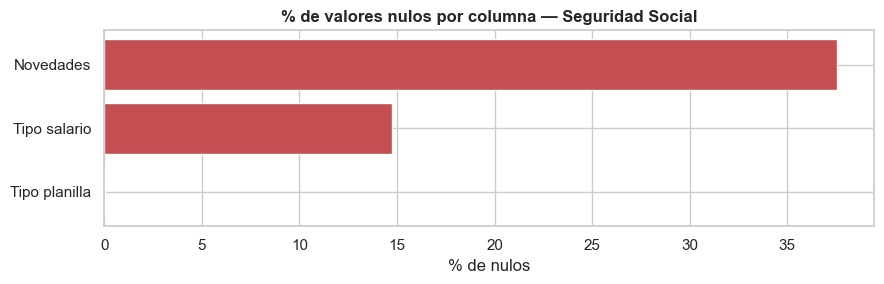

In [7]:
nulos = (ss.isna().mean() * 100).sort_values(ascending=False)
nulos = nulos[nulos > 0]
if len(nulos):
    ax = plot_top(nulos, "% de valores nulos por columna — Seguridad Social", n=len(nulos), color="#c44e52")
    ax.set_xlabel("% de nulos")
    plt.tight_layout(); plt.show()
else:
    print("Sin valores nulos en ninguna columna ✅")

### 4.3 · Cobertura por persona: ¿cuánta historia tiene cada una?
Una persona puede tener varias filas por período (multiempleo o varias planillas), por eso se mira tanto el
número de filas como el número de períodos distintos por persona.

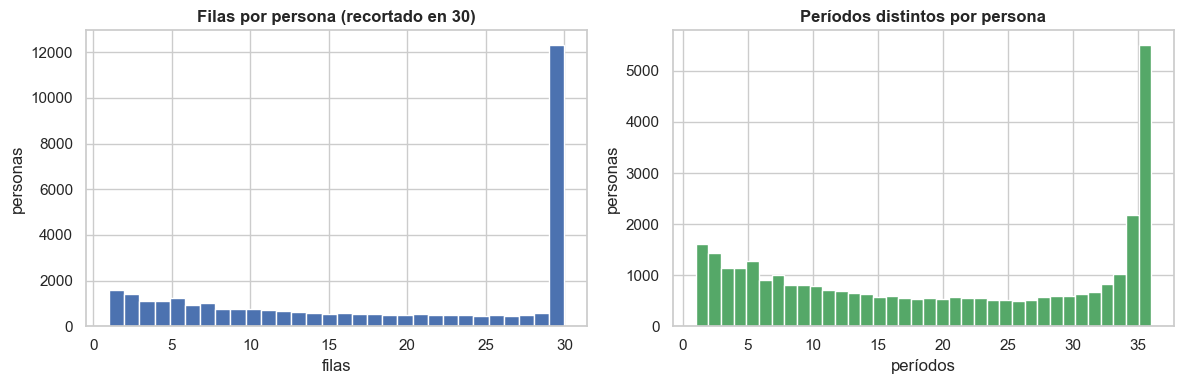

count   33,281.0
mean        22.3
std         16.9
min          1.0
25%          7.0
50%         21.0
75%         35.0
max        374.0



Combinaciones persona-período con MÁS de un empleador (multiempleo): 68,621 de 663,012 (10.3%)


In [8]:
filas_por_persona = ss.groupby("Número de documento").size()
periodos_por_persona = ss.groupby("Número de documento")["Periodo cotización"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(filas_por_persona.clip(upper=30), bins=30, color="#4c72b0", edgecolor="white")
axes[0].set_title("Filas por persona (recortado en 30)")
axes[0].set_xlabel("filas"); axes[0].set_ylabel("personas")
axes[1].hist(periodos_por_persona, bins=int(periodos_por_persona.max()), color="#55a868", edgecolor="white")
axes[1].set_title("Períodos distintos por persona")
axes[1].set_xlabel("períodos"); axes[1].set_ylabel("personas")
plt.tight_layout(); plt.show()

print(filas_por_persona.describe().round(1).to_string())
multi = (ss.groupby(["Número de documento", "Periodo cotización"])["Número documento"].nunique() > 1)
print("\nCombinaciones persona-período con MÁS de un empleador (multiempleo):",
      tasa(int(multi.sum()), len(multi)))

### 4.4 · Dimensión temporal: aportes por período de cotización

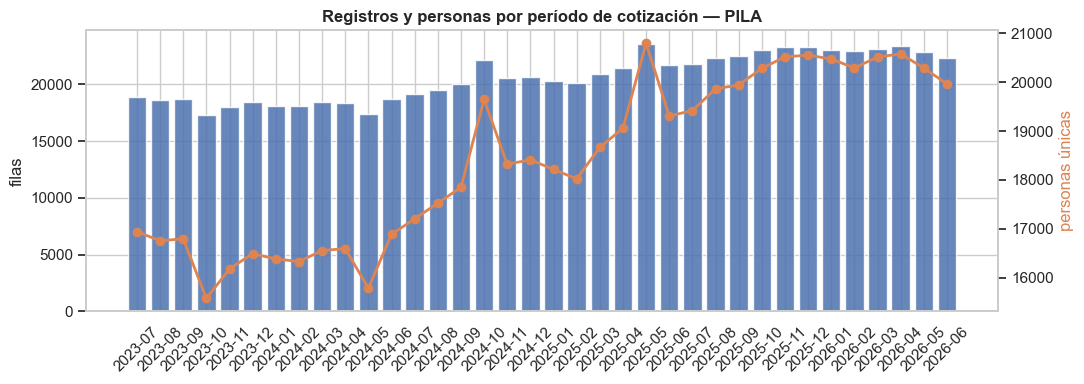

,filas,personas
Periodo cotización,,
2023-07,18892,16940
2023-08,18627,16754
2023-09,18687,16795
2023-10,17292,15572
2023-11,18005,16178
2023-12,18419,16490
2024-01,18140,16382
2024-02,18145,16328
2024-03,18424,16553


In [9]:
por_periodo = ss.groupby("Periodo cotización").agg(
    filas=("Periodo cotización", "size"),
    personas=("Número de documento", "nunique")).sort_index()
fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(por_periodo.index.astype(str), por_periodo["filas"], color="#4c72b0", alpha=.85)
ax1.set_title("Registros y personas por período de cotización — PILA")
ax1.set_ylabel("filas"); ax1.tick_params(axis="x", rotation=45)
ax2 = ax1.twinx()
ax2.plot(por_periodo.index.astype(str), por_periodo["personas"], color="#dd8452", marker="o", lw=2)
ax2.set_ylabel("personas únicas", color="#dd8452"); ax2.grid(False)
plt.tight_layout(); plt.show()
por_periodo

### 4.5 · Variables numéricas: salarios e IBC
El **IBC** es el ingreso sobre el que se cotiza. Aspectos clave: concentración en el SMLV (característica del
mercado laboral colombiano y de la subdeclaración), ceros (subsistemas por los que no se cotiza) y colas largas.

In [10]:
cols_ibc = ["Salario básico", "Ingreso base pensión", "Ingreso base salud",
            "Ingreso base caja compensación", "Ingreso base riesgos"]
ss[cols_ibc].apply(num).describe(percentiles=[.05, .25, .5, .75, .95, .99]).T

,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
Salario básico,"743,406.0","2,933,905.9","4,299,940.8",0.0,"1,160,000.0","1,358,795.0","1,689,853.0","2,740,000.0","8,653,228.0","21,125,000.0","201,423,500.0"
Ingreso base pensión,"743,406.0","796,473.7","2,742,878.2",0.0,0.0,0.0,0.0,0.0,"4,797,635.0","13,759,434.1","79,082,859.0"
Ingreso base salud,"743,406.0","1,993,332.8","3,257,624.9",0.0,0.0,0.0,"1,423,500.0","2,100,000.0","7,359,672.0","16,100,000.0","79,082,859.0"
Ingreso base caja compensación,"743,406.0","351,547.1","1,804,364.9",0.0,0.0,0.0,0.0,0.0,"1,960,761.5","6,871,967.7","505,896,643.0"
Ingreso base riesgos,"743,406.0","1,321,137.2","2,822,908.7",0.0,0.0,0.0,0.0,"1,749,563.5","5,823,462.0","13,769,001.0","43,772,625.0"


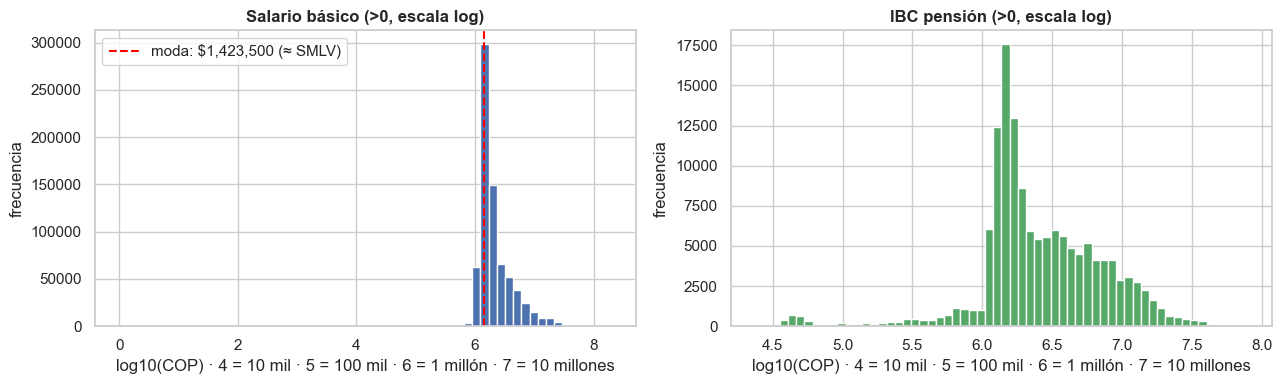

Moda del salario básico (>0): $1,423,500
Filas con salario básico == moda: 104,138 de 743,406 (14.0%)
Filas con salario básico <= moda (en o bajo el mínimo): 298,053 de 739,495 (40.3%)
Filas con IBC pensión == 0 (no cotiza pensión): 603,110 de 743,406 (81.1%)
Filas con IBC salud == 0: 217,080 de 743,406 (29.2%)


In [11]:
sal = num(ss["Salario básico"])
ibc_pen = num(ss["Ingreso base pensión"])
moda_salario = sal[sal > 0].mode().iloc[0]   # la moda del salario suele ser el SMLV vigente

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
hist_log(sal, "Salario básico (>0, escala log)", ax=axes[0], color="#4c72b0")
axes[0].axvline(np.log10(moda_salario), color="red", ls="--",
                label=f"moda: ${moda_salario:,.0f} (≈ SMLV)")
axes[0].legend()
hist_log(ibc_pen, "IBC pensión (>0, escala log)", ax=axes[1], color="#55a868")
plt.tight_layout(); plt.show()

print(f"Moda del salario básico (>0): ${moda_salario:,.0f}")
print("Filas con salario básico == moda:", tasa(int((sal == moda_salario).sum()), len(ss)))
print("Filas con salario básico <= moda (en o bajo el mínimo):",
      tasa(int((sal[sal > 0] <= moda_salario).sum()), int((sal > 0).sum())))
print("Filas con IBC pensión == 0 (no cotiza pensión):", tasa(int((ibc_pen == 0).sum()), len(ss)))
print("Filas con IBC salud == 0:", tasa(int((num(ss["Ingreso base salud"]) == 0).sum()), len(ss)))

### 4.6 · Días cotizados: intensidad laboral del período

In [12]:
cols_dias = ["Días pensión", "Días salud", "Días caja compensación", "Días riesgos"]
dias = ss[cols_dias].apply(num)
print(dias.describe().round(1).T.to_string())
print("\nDistribución de 'Días salud':")
print(ss["Días salud"].value_counts().head(8).to_string())
fuera_rango = ((dias < 0) | (dias > 30)).any(axis=1).sum()
print("\nFilas con algún valor de días fuera del rango [0, 30]:", tasa(int(fuera_rango), len(ss)))

                           count  mean  std  min  25%  50%  75%  max
Días pensión           743,406.0   5.2 11.3  0.0  0.0  0.0  0.0 30.0
Días salud             743,406.0  19.6 13.8  0.0  0.0 30.0 30.0 90.0
Días caja compensación 743,406.0   3.2  9.1  0.0  0.0  0.0  0.0 60.0
Días riesgos           743,406.0  11.8 14.4  0.0  0.0  0.0 30.0 30.0

Distribución de 'Días salud':
Días salud
30    453262
0     213545
1      13099
15      4255
2       3093
3       2584
16      2570
5       2552

Filas con algún valor de días fuera del rango [0, 30]: 203 de 743,406 (0.0%)


### 4.7 · Variables categóricas: quién cotiza, cómo y a través de quién

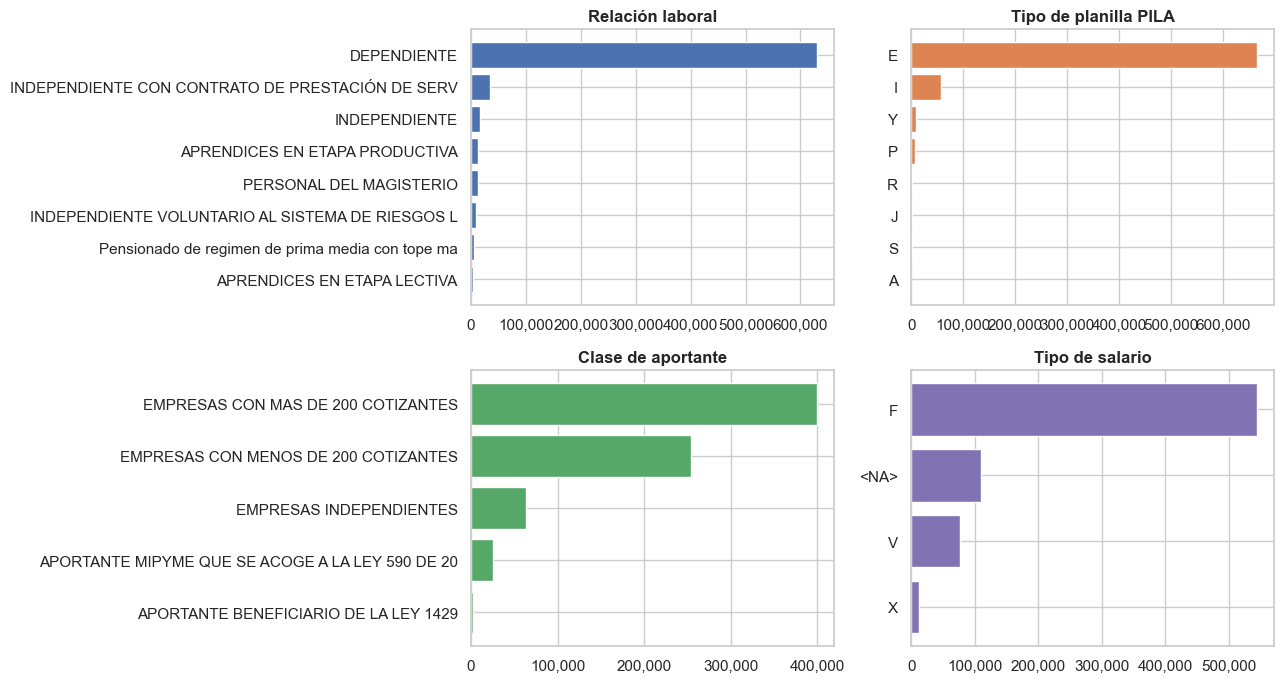

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
plot_top(ss["Relación laboral"].value_counts(dropna=False).rename(index=str),
         "Relación laboral", 8, ax=axes[0, 0])
plot_top(ss["Tipo planilla"].value_counts(dropna=False).rename(index=str),
         "Tipo de planilla PILA", 8, ax=axes[0, 1], color="#dd8452")
plot_top(ss["Clase aportante"].value_counts(dropna=False).rename(index=str),
         "Clase de aportante", 8, ax=axes[1, 0], color="#55a868")
plot_top(ss["Tipo salario"].value_counts(dropna=False).rename(index=str),
         "Tipo de salario", 8, ax=axes[1, 1], color="#8172b3")
plt.tight_layout(); plt.show()

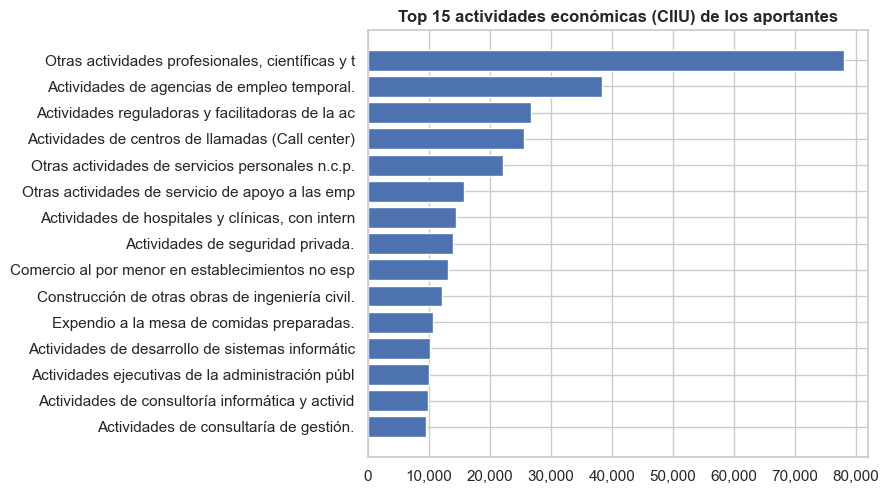

Actividades económicas distintas: 474


In [14]:
plot_top(ss["Actividad económica"].value_counts(),
         "Top 15 actividades económicas (CIIU) de los aportantes", 15)
plt.tight_layout(); plt.show()
print("Actividades económicas distintas:", ss["Actividad económica"].nunique())

### 4.8 · Novedades laborales
Las novedades son las *señales de eventos* que alimentan el caso de uso de **monitoreo y alertas**:
ingreso, retiro, variación de salario, vacaciones, incapacidades, suspensión del contrato/licencia…
El campo trae frases separadas por coma; una novedad («Suspensión temporal del contrato, licencia no
remunerada…») contiene coma interna, por eso se separa solo en comas seguidas de mayúscula.

Filas con alguna novedad: 464,133 de 743,406 (62.4%)


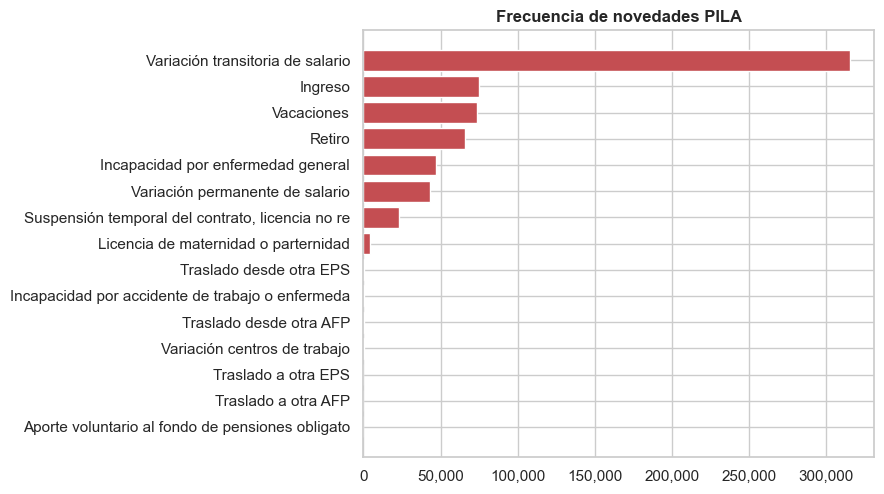

Eventos de novedad totales: 648,962 · tipos distintos: 15


In [15]:
novedad_str = ss["Novedades"].astype(str)
con_novedad = ss["Novedades"].notna() & (novedad_str.str.strip() != "") & (novedad_str.str.lower() != "nan")
print("Filas con alguna novedad:", tasa(int(con_novedad.sum()), len(ss)))
novedades = (novedad_str[con_novedad]
             .str.split(r",(?=[A-ZÁÉÍÓÚÜÑ])", regex=True).explode().str.strip())
novedades = novedades[novedades != ""]
plot_top(novedades.value_counts(), "Frecuencia de novedades PILA", 15, color="#c44e52")
plt.tight_layout(); plt.show()
print(f"Eventos de novedad totales: {len(novedades):,} · tipos distintos: {novedades.nunique()}")

### 4.9 · Consistencia interna: IBC pensión vs IBC salud

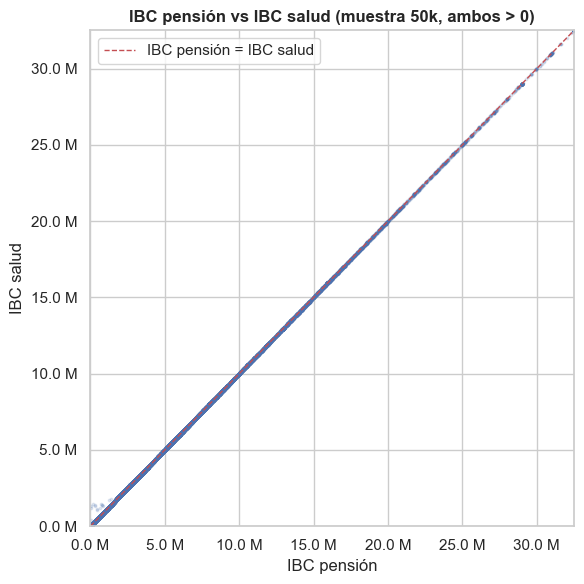

Cuando ambos IBC > 0, coinciden exactamente en el 100.0% de las filas
(Personas que cotizan salud pero no pensión suelen ser pensionados o regímenes especiales)


In [16]:
ambos = pd.DataFrame({"pension": ibc_pen, "salud": num(ss["Ingreso base salud"])})
ambos = ambos[(ambos > 0).all(axis=1)]
muestra = ambos.sample(min(50_000, len(ambos)), random_state=42)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(muestra["pension"], muestra["salud"], s=3, alpha=.15)
lim = float(muestra.quantile(.995).max())
ax.plot([0, lim], [0, lim], "r--", lw=1, label="IBC pensión = IBC salud")
ax.set(xlim=(0, lim), ylim=(0, lim), xlabel="IBC pensión", ylabel="IBC salud",
       title="IBC pensión vs IBC salud (muestra 50k, ambos > 0)")
ax.xaxis.set_major_formatter(fmt_mill); ax.yaxis.set_major_formatter(fmt_mill)
ax.legend(); plt.tight_layout(); plt.show()

iguales = (ambos["pension"] == ambos["salud"]).mean()
print(f"Cuando ambos IBC > 0, coinciden exactamente en el {iguales:.1%} de las filas")
print(f"(Personas que cotizan salud pero no pensión suelen ser pensionados o regímenes especiales)")

### 4.10 · Síntesis del dataset (calculada sobre los datos)

In [17]:
print(f"""RESUMEN — SEGURIDAD SOCIAL (PILA)
- {len(ss):,} aportes · {n_personas_ss:,} personas · {n_empleadores:,} aportantes
- Períodos: {ss['Periodo cotización'].min()} a {ss['Periodo cotización'].max()}
- Mediana salario básico (>0): ${sal[sal>0].median():,.0f} · media: ${sal[sal>0].mean():,.0f} (cola larga a la derecha)
- {(sal == moda_salario).mean():.1%} de las filas con salario exactamente en la moda (${moda_salario:,.0f} ≈ SMLV)
- {(ibc_pen == 0).mean():.1%} de las filas NO cotizan pensión (IBC pensión = 0) → señal de pensionados/regímenes especiales/informalidad
- Filas con novedades: {con_novedad.mean():.1%} → insumo del caso de uso 'Monitoreo y alertas'
- Multiempleo persona-período: {multi.mean():.1%}""")

RESUMEN — SEGURIDAD SOCIAL (PILA)
- 743,406 aportes · 33,281 personas · 29,957 aportantes
- Períodos: 2023-07 a 2026-06
- Mediana salario básico (>0): $1,700,000 · media: $2,949,423 (cola larga a la derecha)
- 14.0% de las filas con salario exactamente en la moda ($1,423,500 ≈ SMLV)
- 81.1% de las filas NO cotizan pensión (IBC pensión = 0) → señal de pensionados/regímenes especiales/informalidad
- Filas con novedades: 62.4% → insumo del caso de uso 'Monitoreo y alertas'
- Multiempleo persona-período: 10.3%


---
## 5 · EDA Dataset 2 — Transferencias ACH / Transfiya

**Qué es:** movimientos interbancarios de las personas consultadas por los dos rieles de ACH Colombia:
**ACH** (transferencias tradicionales, en lotes) y **Transfiya** (transferencias inmediatas de bajo monto).
Cada fila es un agregado *persona × período × contraparte*, con columnas de resumen del período
(totales enviados/recibidos) y columnas de detalle (entidades, usuarios, cantidad y valor).

**Por qué importa para el negocio:** es el *flujo real de dinero observado* — núcleo de los casos de uso
2 (ingresos independientes: `valorRecibido` recurrente), 3 (flujo de caja) y 1 (alertas por caída de flujos).

> ⚠️ **Nota:** el archivo trae 1.048.574 filas de datos = tope máximo de una hoja de Excel.
> Es casi seguro que el extracto quedó **truncado** al exportarse; se verifica abajo.

### 5.1 · Estructura general

In [18]:
resumen_estructura(ach)

,tipo,no_nulos,%_nulos,n_unicos,ejemplo
Nombre,string[pyarrow],1048574,0.0,25527,************O
Tipo documento,string[pyarrow],1048574,0.0,1,P
Número documento,string[pyarrow],1048574,0.0,26904,23200004****
Promedio ACH recibidas,int64[pyarrow],1048574,0.0,21072,138565
Promedio Transfiya recibidas,int64[pyarrow],1048574,0.0,20334,1549920
Promedio ACH enviadas,int64[pyarrow],1048574,0.0,8927,13000
Promedio Transfiya enviadas,int64[pyarrow],1048574,0.0,17237,1728130
Periodo,string[pyarrow],1048574,0.0,18,2026-02
Total recibidas periodo,double[pyarrow],1048574,0.0,120210,323900.0
Cantidad recibidas periodo,int64[pyarrow],1048574,0.0,200,2


In [19]:
print("Dimensiones:", f"{ach.shape[0]:,} filas x {ach.shape[1]} columnas")
print("Duplicados exactos:", tasa(ach.duplicated().sum(), len(ach)))
n_personas_ach = ach["Número documento"].nunique()
print("Personas únicas (documento ofuscado):", f"{n_personas_ach:,}")
print("Períodos:", ach["Periodo"].min(), "→", ach["Periodo"].max(), f"({ach['Periodo'].nunique()} períodos)")
print("\n¿Truncado en el límite de Excel (1.048.576 filas incl. encabezado)?:",
      "SÍ ⚠️" if len(ach) >= 1_048_574 else "no")

Dimensiones: 1,048,574 filas x 26 columnas


Duplicados exactos: 7,291 de 1,048,574 (0.7%)
Personas únicas (documento ofuscado): 26,904


Períodos: 2025-01 → 2026-06 (18 períodos)

¿Truncado en el límite de Excel (1.048.576 filas incl. encabezado)?: SÍ ⚠️


### 5.2 · Calidad: valores nulos
Los nulos de las columnas de contraparte son **estructurales**, no errores: en los registros `ENVIADO`
la persona consultada es el origen (los campos de origen quedan vacíos) y en los `RECIBIDO` es el destino
(los campos de destino quedan vacíos). Se verifica cruzando el % de nulos con `Tipo registro`.

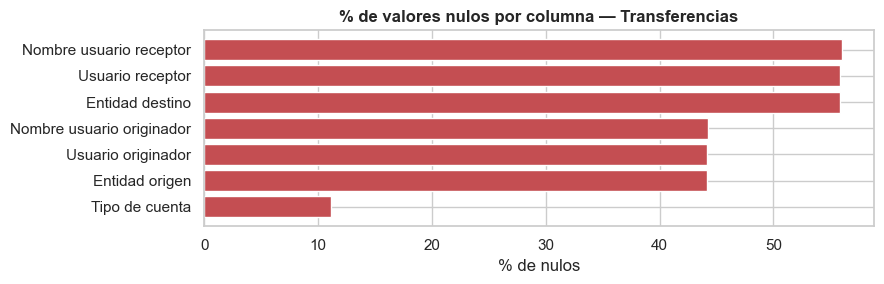

Filas ENVIADO: 44.1% ≈ % de nulos en columnas de ORIGEN → nulos estructurales
Filas RECIBIDO: 55.9% ≈ % de nulos en columnas de DESTINO → nulos estructurales


In [20]:
nulos = (ach.isna().mean() * 100).sort_values(ascending=False)
nulos = nulos[nulos > 0]
if len(nulos):
    ax = plot_top(nulos, "% de valores nulos por columna — Transferencias", n=len(nulos), color="#c44e52")
    ax.set_xlabel("% de nulos"); plt.tight_layout(); plt.show()
    pct_env = float(ach["Tipo registro"].astype(str).str.upper().eq("ENVIADO").mean()) * 100
    print(f"Filas ENVIADO: {pct_env:.1f}% ≈ % de nulos en columnas de ORIGEN → nulos estructurales")
    print(f"Filas RECIBIDO: {100 - pct_env:.1f}% ≈ % de nulos en columnas de DESTINO → nulos estructurales")
else:
    print("Sin valores nulos ✅")

### 5.3 · Composición: riel (`Servicio`) y sentido del flujo (`Tipo registro`)

filas       valor_total  personas
Servicio  Tipo registro                                    
ACH       ENVIADO        117264  70,078,066,661.0     13904
          RECIBIDO       252205 394,435,708,816.2     21949
TRANSFIYA ENVIADO        345477 107,879,113,171.7     21069
          RECIBIDO       333628 124,350,193,855.9     23081

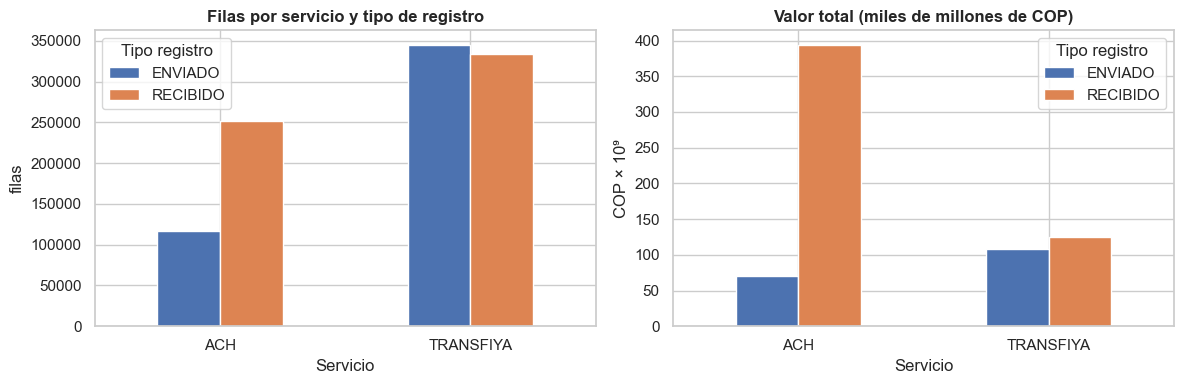

In [21]:
valor_ach = num(ach["Valor"])
comp = (ach.assign(valor=valor_ach)
        .groupby(["Servicio", "Tipo registro"], dropna=False)
        .agg(filas=("valor", "size"), valor_total=("valor", "sum"),
             personas=("Número documento", "nunique")))
display(comp)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
comp["filas"].unstack().plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("Filas por servicio y tipo de registro"); axes[0].set_ylabel("filas")
(comp["valor_total"] / 1e9).unstack().plot(kind="bar", ax=axes[1], rot=0)
axes[1].set_title("Valor total (miles de millones de COP)"); axes[1].set_ylabel("COP × 10⁹")
plt.tight_layout(); plt.show()

### 5.4 · Montos: distribución del valor

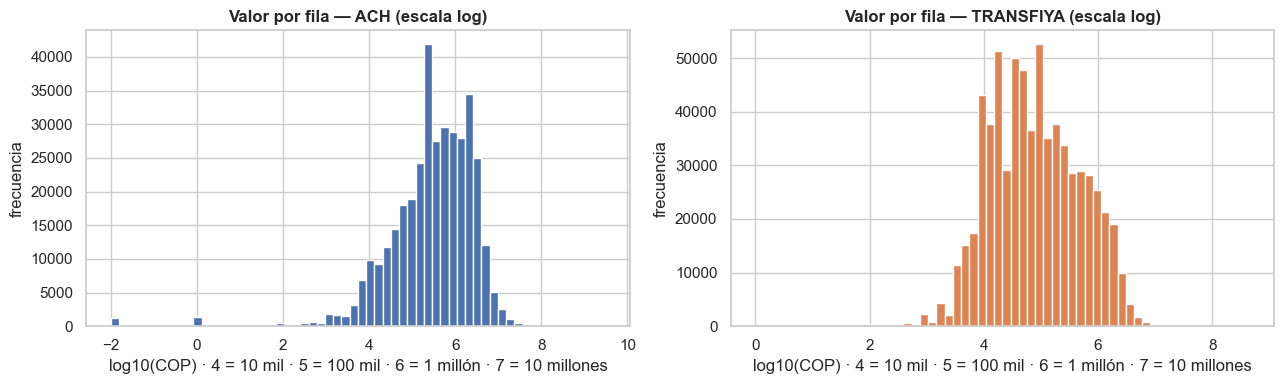

count       1,048,574.0
mean          664,467.0
std         4,238,615.0
min                 0.0
5%              5,000.0
25%            26,650.0
50%           123,000.0
75%           569,040.0
95%         2,776,000.0
99%         6,400,000.0
max     3,000,000,000.0


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
serv = ach["Servicio"].astype(str).str.upper()
for axi, (nombre_serv, color) in zip(axes, [("ACH", "#4c72b0"), ("TRANSFIYA", "#dd8452")]):
    hist_log(ach.loc[serv == nombre_serv, "Valor"],
             f"Valor por fila — {nombre_serv} (escala log)", ax=axi, color=color)
plt.tight_layout(); plt.show()

print(valor_ach.describe(percentiles=[.05, .25, .5, .75, .95, .99]).round(0).to_string())

### 5.5 · Dimensión temporal: flujos por período

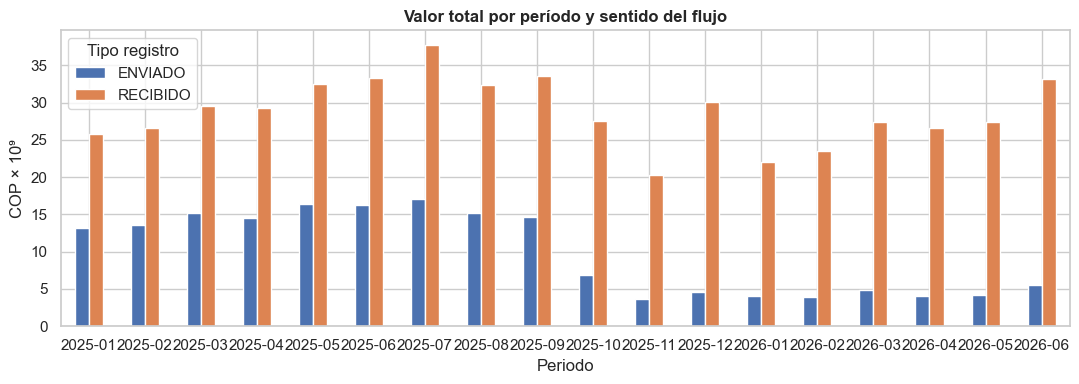

,filas,personas
Periodo,,
2025-01,83988,18917
2025-02,88329,19175
2025-03,95969,19721
2025-04,86779,18993
2025-05,91850,19129
2025-06,89649,18966
2025-07,93655,19468
2025-08,91411,19084
2025-09,92618,19047


In [23]:
por_per = (ach.assign(valor=valor_ach)
           .groupby(["Periodo", "Tipo registro"])["valor"].sum().unstack() / 1e9)
fig, ax = plt.subplots(figsize=(11, 4))
por_per.plot(kind="bar", ax=ax, rot=0)
ax.set_title("Valor total por período y sentido del flujo")
ax.set_ylabel("COP × 10⁹")
plt.tight_layout(); plt.show()
ach.groupby("Periodo").agg(filas=("Periodo", "size"), personas=("Número documento", "nunique"))

### 5.6 · Contrapartes: entidades, tipo de cuenta y transferencias a cuentas propias

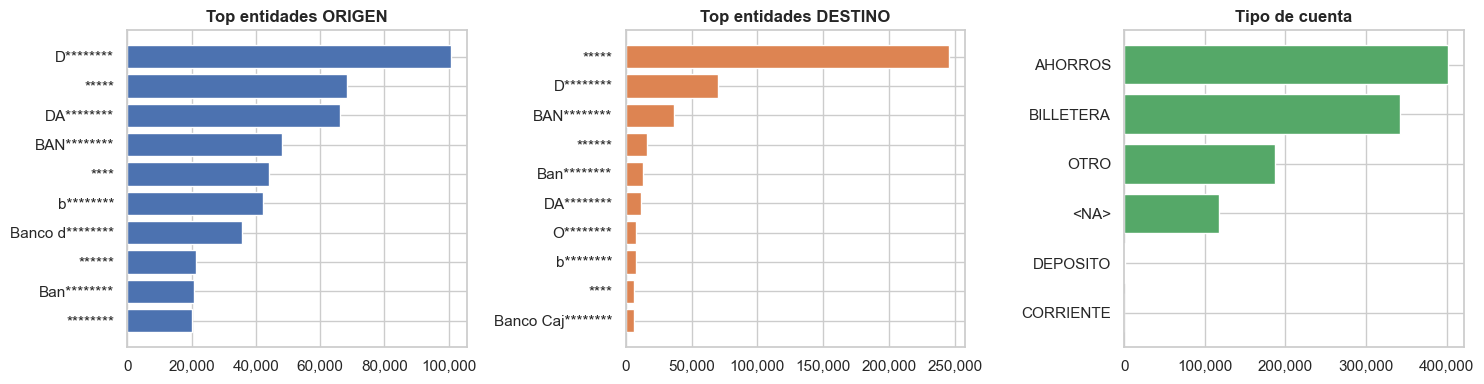

Distribución de 'Cuenta propia':
Cuenta propia
NO    846673
SI    201901


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_top(ach["Entidad origen"].value_counts(), "Top entidades ORIGEN", 10, ax=axes[0])
plot_top(ach["Entidad destino"].value_counts(), "Top entidades DESTINO", 10, ax=axes[1], color="#dd8452")
plot_top(ach["Tipo de cuenta"].value_counts(dropna=False).rename(index=str),
         "Tipo de cuenta", 8, ax=axes[2], color="#55a868")
plt.tight_layout(); plt.show()
print("Distribución de 'Cuenta propia':")
print(ach["Cuenta propia"].value_counts(dropna=False).to_string())

### 5.7 · Perfil por persona: recibido vs enviado (columnas de resumen)
Las columnas `Promedio *` se repiten por persona: basta tomar la primera fila de cada una.
El **flujo neto** (recibido − enviado) es la semilla del caso de uso 3 (flujo de caja).

       recibido_total  enviado_total     flujo_neto
count        26,904.0       26,904.0       26,904.0
mean      1,879,032.0      912,028.0      967,004.0
std       5,091,119.0    2,733,495.0    5,007,210.0
min               0.0            0.0 -138,110,107.0
25%         262,500.0       32,000.0        1,774.0
50%         933,500.0      293,536.0      318,592.0
75%       2,276,744.0      999,812.0    1,391,607.0
95%       5,943,006.0    3,124,745.0    4,391,746.0
max     422,958,202.0  142,700,000.0  422,958,202.0

Personas con flujo neto POSITIVO (reciben más de lo que envían): 75.3%


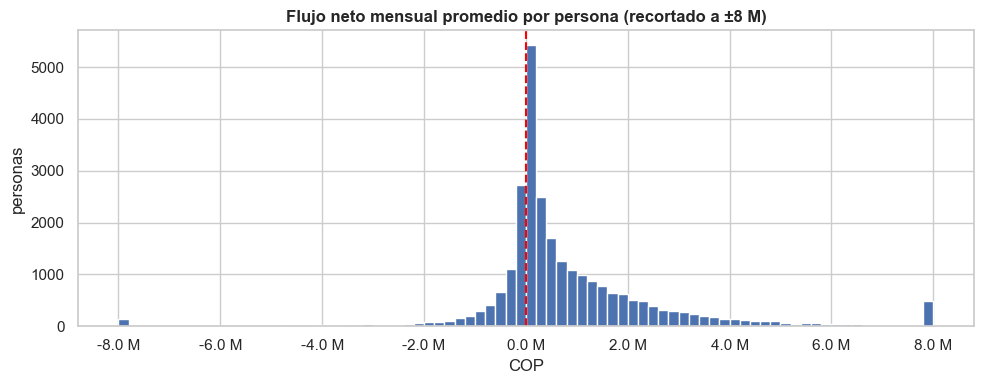

In [25]:
resumen_persona = (ach.groupby("Número documento")
                   .agg(prom_ach_rec=("Promedio ACH recibidas", "first"),
                        prom_tfy_rec=("Promedio Transfiya recibidas", "first"),
                        prom_ach_env=("Promedio ACH enviadas", "first"),
                        prom_tfy_env=("Promedio Transfiya enviadas", "first"))
                   .apply(num))
resumen_persona["recibido_total"] = resumen_persona[["prom_ach_rec", "prom_tfy_rec"]].sum(axis=1)
resumen_persona["enviado_total"]  = resumen_persona[["prom_ach_env", "prom_tfy_env"]].sum(axis=1)
resumen_persona["flujo_neto"]     = resumen_persona["recibido_total"] - resumen_persona["enviado_total"]

print(resumen_persona[["recibido_total", "enviado_total", "flujo_neto"]]
      .describe(percentiles=[.25, .5, .75, .95]).round(0).to_string())
neto_pos = (resumen_persona["flujo_neto"] > 0).mean()
print(f"\nPersonas con flujo neto POSITIVO (reciben más de lo que envían): {neto_pos:.1%}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(resumen_persona["flujo_neto"].clip(-8e6, 8e6), bins=80, color="#4c72b0", edgecolor="white")
ax.axvline(0, color="red", ls="--")
ax.set_title("Flujo neto mensual promedio por persona (recortado a ±8 M)")
ax.xaxis.set_major_formatter(fmt_mill); ax.set_xlabel("COP"); ax.set_ylabel("personas")
plt.tight_layout(); plt.show()

### 5.8 · Síntesis del dataset (calculada sobre los datos)

In [26]:
pct_tfy = (serv == "TRANSFIYA").mean()
pct_rec = ach["Tipo registro"].astype(str).str.upper().eq("RECIBIDO").mean()
print(f"""RESUMEN — TRANSFERENCIAS ACH/TRANSFIYA
- {len(ach):,} filas · {n_personas_ach:,} personas · períodos {ach['Periodo'].min()} a {ach['Periodo'].max()}
- {"⚠️ Archivo truncado en el límite de filas de Excel → la historia de algunas personas queda incompleta" if len(ach) >= 1_048_574 else "Sin truncamiento aparente"}
- Transfiya: {pct_tfy:.1%} de las filas · registros RECIBIDO: {pct_rec:.1%}
- Valor mediano por fila: ${valor_ach.median():,.0f} · p95: ${valor_ach.quantile(.95):,.0f} (colas muy largas)
- {neto_pos:.1%} de las personas con flujo neto positivo → insumo directo del caso de uso 'Flujo de caja'""")

RESUMEN — TRANSFERENCIAS ACH/TRANSFIYA
- 1,048,574 filas · 26,904 personas · períodos 2025-01 a 2026-06
- ⚠️ Archivo truncado en el límite de filas de Excel → la historia de algunas personas queda incompleta
- Transfiya: 64.8% de las filas · registros RECIBIDO: 55.9%
- Valor mediano por fila: $123,000 · p95: $2,776,000 (colas muy largas)
- 75.3% de las personas con flujo neto positivo → insumo directo del caso de uso 'Flujo de caja'


---
## 6 · EDA Dataset 3 — Pagos Digitales (PSE)

**Qué es:** pagos hechos por las personas a través de **PSE**. Cada fila es un agregado
*persona × período × comercio*: a qué comercio pagó, cuántas veces (`Cantidad`) y por cuánto (`Valor`),
más columnas de resumen del período.

**Por qué importa para el negocio:** el campo `Comercio` es el **mapa de consumo** de la persona
(caso de uso 4) y la base de la taxonomía de categorías (gobierno, financiero, streaming, turismo, salud,
educación…).

> ⚠️ También llega al tope de filas de Excel → verificar truncamiento.

### 6.1 · Estructura general

In [27]:
resumen_estructura(pse)

,tipo,no_nulos,%_nulos,n_unicos,ejemplo
Nombre,string[pyarrow],1048574,0.0,27789,************O
Tipo documento,string[pyarrow],1048574,0.0,1,P
Número documento,string[pyarrow],1048574,0.0,29856,23200004****
Promedio pagos digitales,int64[pyarrow],1048574,0.0,33580,600074
Periodo,string[pyarrow],1048574,0.0,18,2026-06
Total pagos periodo,double[pyarrow],1048574,0.0,252435,411053.64
Cantidad pagos periodo,int64[pyarrow],1048574,0.0,210,9
Valor promedio periodo,double[pyarrow],1048574,0.0,261151,45672.63
Entidad autorizadora,string[pyarrow],1048574,0.0,37,*****
Comercio,string[pyarrow],1048574,0.0,3475,PEXTO COLO********


In [28]:
print("Dimensiones:", f"{pse.shape[0]:,} filas x {pse.shape[1]} columnas")
print("Duplicados exactos:", tasa(pse.duplicated().sum(), len(pse)))
n_personas_pse = pse["Número documento"].nunique()
print("Personas únicas (documento ofuscado):", f"{n_personas_pse:,}")
print("Períodos:", pse["Periodo"].min(), "→", pse["Periodo"].max(), f"({pse['Periodo'].nunique()} períodos)")
print("Comercios distintos (ofuscados):", f"{pse['Comercio'].nunique():,}")
print("\n¿Truncado en el límite de Excel?:", "SÍ ⚠️" if len(pse) >= 1_048_574 else "no")

Dimensiones: 1,048,574 filas x 12 columnas


Duplicados exactos: 1 de 1,048,574 (0.0%)
Personas únicas (documento ofuscado): 29,856


Períodos: 2025-01 → 2026-06 (18 períodos)
Comercios distintos (ofuscados): 3,475

¿Truncado en el límite de Excel?: SÍ ⚠️


### 6.2 · Calidad: valores nulos

In [29]:
nulos = (pse.isna().mean() * 100).sort_values(ascending=False)
nulos = nulos[nulos > 0]
if len(nulos):
    ax = plot_top(nulos, "% de valores nulos por columna — Pagos Digitales", n=len(nulos), color="#c44e52")
    ax.set_xlabel("% de nulos"); plt.tight_layout(); plt.show()
else:
    print("Sin valores nulos ✅")

Sin valores nulos ✅


### 6.3 · Comercios: dónde paga la gente

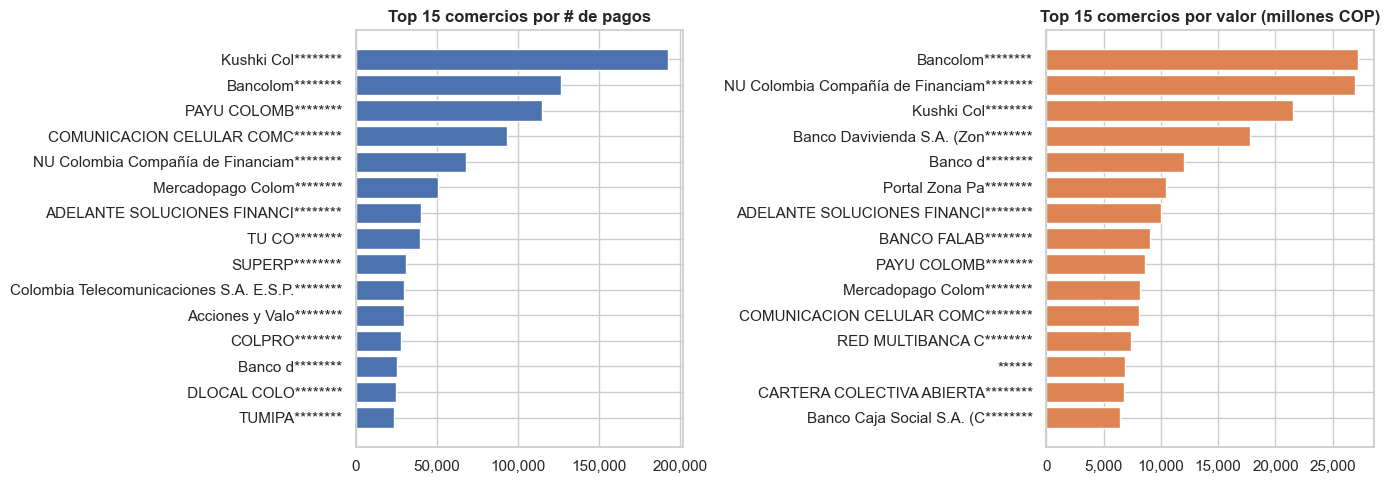

In [30]:
pse_num = pse.assign(valor=num(pse["Valor"]), cantidad=num(pse["Cantidad"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_top(pse_num.groupby("Comercio")["cantidad"].sum().sort_values(ascending=False),
         "Top 15 comercios por # de pagos", 15, ax=axes[0])
plot_top(pse_num.groupby("Comercio")["valor"].sum().sort_values(ascending=False) / 1e6,
         "Top 15 comercios por valor (millones COP)", 15, ax=axes[1], color="#dd8452")
plt.tight_layout(); plt.show()

### 6.4 · Categorización heurística del gasto
Los nombres de comercio están ofuscados al final (`PAYU COLOMB********`), pero el prefijo visible permite una
clasificación temática aproximada por palabras clave — el germen de la **taxonomía de consumo** del caso de uso 4.
La categoría "Pasarelas / agregadores" advierte además un reto: parte del gasto queda oculto detrás del agregador.

,valor_millones,pagos,personas
categoria,,,
Otros / no clasificado,"189,770.0","849,611.0",28239
Financiero / créditos,"157,972.0","415,385.0",19557
Pasarelas / agregadores,"43,531.0","384,614.0",20494
Educación,"13,238.0","21,402.0",6446
Telco / servicios públicos,"5,966.0","55,370.0",8966
Gobierno / impuestos,"5,781.0","20,496.0",4999
Seguros,"4,748.0","10,665.0",4117
Comercio electrónico / retail,"2,510.0","12,959.0",6605
Viajes / transporte,"1,562.0","4,364.0",1962


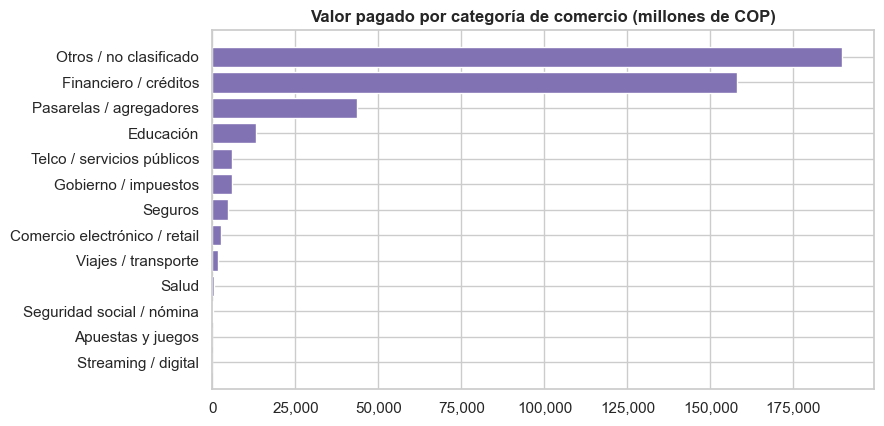

Cobertura de la clasificación heurística: 46.1% de las filas


In [31]:
CATEGORIAS = {
    "Pasarelas / agregadores": ["PAYU", "KUSHKI", "EPAYCO", "PLACETOPAY", "PLACE TO PAY", "MERCADOPAGO",
                                "MERCADO PAGO", "WOMPI", "PAYVALIDA", "PAGOSONLINE", "TU COMPRA", "PAYZEN",
                                "PEXTO", "COBRE"],
    "Financiero / créditos": ["BANCO", "BANCOL", "DAVIVIEN", "NEQUI", "DAVIPLATA", "CREDITO", "CRÉDITO",
                              "FINANC", "COOPERATIVA", "FONDO", "SUFI", "TARJETA", "LULO", "RAPPIPAY",
                              "ADDI", "SISTECREDITO", "COLTEFINANCIERA", "JURISCOOP", "CONFIAR", "SCOTIA",
                              "ITAU", "ITAÚ", "BBVA", "COLPATRIA", "AV VILLAS", "POPULAR", "PICHINCHA",
                              "FALABELLA CMR", "SERFINANZA", "FINANDINA", "BANCAMIA", "MIBANCO"],
    "Apuestas y juegos": ["BETPLAY", "WPLAY", "RUSHBET", "LUCKIA", "CODERE", "STAKE", "BWIN", "APUESTA",
                          "RIVALO", "YAJUEGO", "SPORTIUM", "MEGAPUESTA", "BETSSON", "ZAMBA", "GANA"],
    "Gobierno / impuestos": ["HACIENDA", "ALCALDIA", "ALCALDÍA", "GOBERNACION", "GOBERNACIÓN", "DIAN",
                             "SECRETARIA", "SECRETARÍA", "MUNICIPIO", "TRANSITO", "TRÁNSITO", "RUNT",
                             "REGISTRADURIA", "DISTRIT", "MINISTERIO", "FISCAL", "POLICIA", "IMPUESTO"],
    "Seguridad social / nómina": ["SOI", "APORTES EN LINEA", "APORTES EN LÍNEA", "ARUS", "MI PLANILLA",
                                  "COLPENSIONES", "PROTECCION", "PROTECCIÓN", "PORVENIR", "COMPENSAR",
                                  "COLFONDOS", "SIMPLE S.A", "ASOPAGOS", "ENLACE OPERATIVO"],
    "Telco / servicios públicos": ["CLARO", "MOVISTAR", "TIGO", "WOM ", "ETB", "EPM", "CODENSA", "ENEL",
                                   "VANTI", "GASES", "ACUEDUCTO", "AIRE", "AFINIA", "EMCALI", "CELSIA",
                                   "ESSA", "ELECTRIFICADORA", "ENERGIA", "ENERGÍA"],
    "Comercio electrónico / retail": ["MERCADOLIBRE", "MERCADO LIBRE", "AMAZON", "ALIEXPRESS", "FALABELLA",
                                      "EXITO", "ÉXITO", "OLIMPICA", "OLÍMPICA", "ALKOSTO", "KTRONIX", "TEMU",
                                      "SHEIN", "LINIO", "HOMECENTER", "JUMBO", "MAKRO", "PRICESMART", "D1 ",
                                      "ARA ", "SODIMAC"],
    "Streaming / digital": ["NETFLIX", "SPOTIFY", "DISNEY", "HBO", "PARAMOUNT", "APPLE", "GOOGLE",
                            "MICROSOFT", "PLAYSTATION", "STEAM", "TWITCH", "PRIME", "CRUNCHYROLL"],
    "Educación": ["UNIVERSIDAD", "ICETEX", "COLEGIO", "ICFES", "SENA", "ACADEM", "EDUCA", "POLITECNICO",
                  "POLITÉCNICO", "UNIMINUTO", "CORPORACION UNIV", "FUNDACION UNIV", "GIMNASIO", "LICEO"],
    "Viajes / transporte": ["AVIANCA", "LATAM", "VIVA", "WINGO", "SATENA", "BOOKING", "DESPEGAR", "AEROL",
                            "HOTEL", "EXPRESO", "BOLIVARIANO", "TERMINAL", "UBER", "DIDI", "CABIFY",
                            "REDBUS", "PULLMAN"],
    "Salud": ["EPS", "FARMAC", "DROGUERIA", "DROGUERÍA", "CLINICA", "CLÍNICA", "HOSPITAL", "SANITAS",
              "COLSANITAS", "MEDPLUS", "AUDIFARMA", "CRUZ VERDE", "COLSUBSIDIO", "SALUD", "LABORATORIO"],
    "Seguros": ["SEGURO", "ALLIANZ", "MAPFRE", "AXA", "BOLIVAR", "BOLÍVAR", "LIBERTY", "PREVISORA",
                "MUNDIAL", "SOAT", "HDI", "CHUBB", "SBS"],
}

def categorizar(nombre: str) -> str:
    n = str(nombre).upper()
    for cat, claves in CATEGORIAS.items():
        if any(k in n for k in claves):
            return cat
    return "Otros / no clasificado"

mapa_categoria = {c: categorizar(c) for c in pse["Comercio"].dropna().unique()}
pse_num["categoria"] = pse["Comercio"].astype(str).map(mapa_categoria).fillna("Otros / no clasificado")

resumen_cat = (pse_num.groupby("categoria")
               .agg(valor_millones=("valor", lambda s: s.sum() / 1e6),
                    pagos=("cantidad", "sum"),
                    personas=("Número documento", "nunique"))
               .sort_values("valor_millones", ascending=False))
display(resumen_cat.round(0))

plot_top(resumen_cat["valor_millones"], "Valor pagado por categoría de comercio (millones de COP)",
         n=len(resumen_cat), color="#8172b3")
plt.tight_layout(); plt.show()
cobertura = float((pse_num["categoria"] != "Otros / no clasificado").mean())
print(f"Cobertura de la clasificación heurística: {cobertura:.1%} de las filas")

### 6.5 · Montos y frecuencia de pago

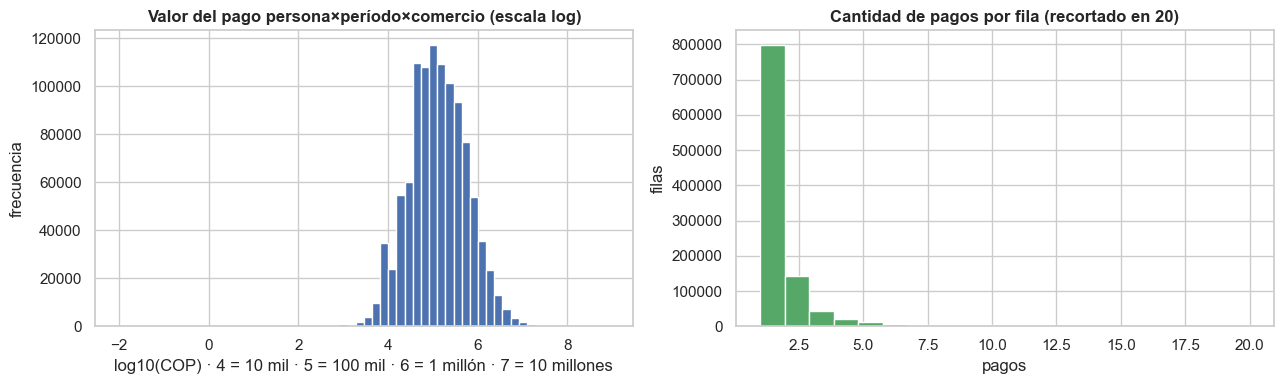

              valor    cantidad
count   1,048,574.0 1,048,574.0
mean      406,064.0         1.7
std     1,722,992.6         3.2
min             0.0         1.0
25%        47,000.0         1.0
50%       122,989.0         1.0
75%       354,558.8         1.0
95%     1,500,000.0         4.0
99%     4,295,079.1        12.0
max   823,715,000.0       321.0


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
hist_log(pse_num["valor"], "Valor del pago persona×período×comercio (escala log)", ax=axes[0], color="#4c72b0")
axes[1].hist(pse_num["cantidad"].clip(upper=20), bins=20, color="#55a868", edgecolor="white")
axes[1].set_title("Cantidad de pagos por fila (recortado en 20)")
axes[1].set_xlabel("pagos"); axes[1].set_ylabel("filas")
plt.tight_layout(); plt.show()
print(pse_num[["valor", "cantidad"]].describe(percentiles=[.25, .5, .75, .95, .99]).round(1).to_string())

### 6.6 · Dimensión temporal: gasto PSE por período

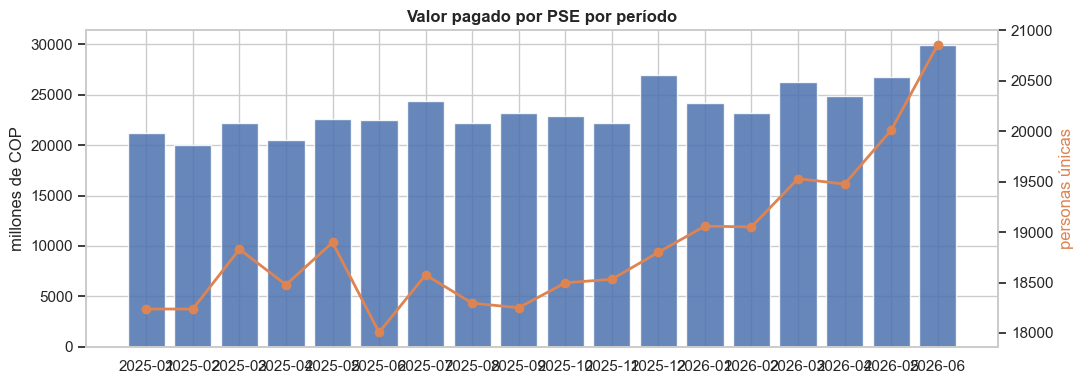

,valor_millones,filas,personas
Periodo,,,
2025-01,"21,231.8",54009,18237
2025-02,"19,996.1",52780,18237
2025-03,"22,167.4",56666,18830
2025-04,"20,550.8",53094,18478
2025-05,"22,557.5",56879,18897
2025-06,"22,493.6",54798,18005
2025-07,"24,385.4",57893,18576
2025-08,"22,163.3",55290,18295
2025-09,"23,146.3",55283,18250


In [33]:
por_per = pse_num.groupby("Periodo").agg(valor_millones=("valor", lambda s: s.sum() / 1e6),
                                         filas=("valor", "size"),
                                         personas=("Número documento", "nunique")).sort_index()
fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(por_per.index.astype(str), por_per["valor_millones"], color="#4c72b0", alpha=.85)
ax1.set_title("Valor pagado por PSE por período"); ax1.set_ylabel("millones de COP")
ax2 = ax1.twinx()
ax2.plot(por_per.index.astype(str), por_per["personas"], color="#dd8452", marker="o", lw=2)
ax2.set_ylabel("personas únicas", color="#dd8452"); ax2.grid(False)
plt.tight_layout(); plt.show()
por_per

### 6.7 · Síntesis del dataset (calculada sobre los datos)

In [34]:
gasto_persona_mes = pse_num.groupby(["Número documento", "Periodo"])["valor"].sum()
print(f"""RESUMEN — PAGOS DIGITALES (PSE)
- {len(pse):,} filas · {n_personas_pse:,} personas · {pse['Comercio'].nunique():,} comercios
- Períodos: {pse['Periodo'].min()} a {pse['Periodo'].max()}
- {"⚠️ Archivo truncado en el límite de filas de Excel" if len(pse) >= 1_048_574 else "Sin truncamiento aparente"}
- Valor mediano por fila: ${pse_num['valor'].median():,.0f} · gasto mediano persona-mes: ${gasto_persona_mes.median():,.0f}
- Cobertura de la taxonomía heurística de comercios: {cobertura:.1%} de las filas
- Las categorías dominantes por valor (§6.4) son la base del caso de uso 'Comportamientos de consumo'""")

RESUMEN — PAGOS DIGITALES (PSE)
- 1,048,574 filas · 29,856 personas · 3,475 comercios
- Períodos: 2025-01 a 2026-06
- ⚠️ Archivo truncado en el límite de filas de Excel
- Valor mediano por fila: $122,989 · gasto mediano persona-mes: $413,781
- Cobertura de la taxonomía heurística de comercios: 46.1% de las filas
- Las categorías dominantes por valor (§6.4) son la base del caso de uso 'Comportamientos de consumo'


---
## 7 · Cruce entre datasets — hacia la visión 360° de la persona

La propuesta de valor de ACH Data es la **triangulación**: ingreso declarado (SS) vs dinero recibido
(ACH/Transfiya) vs gasto (PSE). Aquí se mide cuántas personas (por documento ofuscado) aparecen en cada
combinación de fuentes.

> El documento ofuscado conserva solo los primeros dígitos (`23200004****`), por lo que el cruce es un
> **cuasi-emparejamiento**: sirve para dimensionar el solapamiento, no para un match exacto en producción.

,personas,%_del_universo
Solo Seguridad Social,8728,21.3
Solo Transferencias,695,1.7
Solo PSE,639,1.6
SS ∩ Transferencias,1613,3.9
SS ∩ PSE,4621,11.3
Transferencias ∩ PSE,6277,15.4
Las 3 fuentes,18319,44.8


Universo total de documentos distintos: 40,892
Personas con las TRES fuentes (visión 360° completa): 18,319 (44.8% del universo)


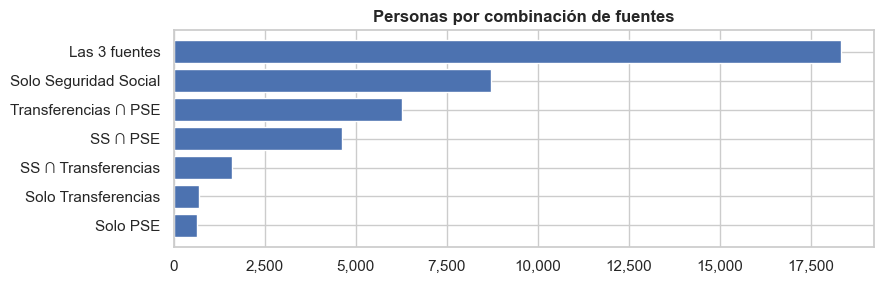

In [35]:
docs_ss  = set(ss["Número de documento"].dropna().astype(str))
docs_ach = set(ach["Número documento"].dropna().astype(str))
docs_pse = set(pse["Número documento"].dropna().astype(str))

combos = {
    "Solo Seguridad Social": len(docs_ss - docs_ach - docs_pse),
    "Solo Transferencias":   len(docs_ach - docs_ss - docs_pse),
    "Solo PSE":              len(docs_pse - docs_ss - docs_ach),
    "SS ∩ Transferencias":   len((docs_ss & docs_ach) - docs_pse),
    "SS ∩ PSE":              len((docs_ss & docs_pse) - docs_ach),
    "Transferencias ∩ PSE":  len((docs_ach & docs_pse) - docs_ss),
    "Las 3 fuentes":         len(docs_ss & docs_ach & docs_pse),
}
total_universo = len(docs_ss | docs_ach | docs_pse)
tabla = pd.DataFrame({"personas": combos})
tabla["%_del_universo"] = (tabla["personas"] / total_universo * 100).round(1)
display(tabla)
print(f"Universo total de documentos distintos: {total_universo:,}")
print(f"Personas con las TRES fuentes (visión 360° completa): {combos['Las 3 fuentes']:,} "
      f"({combos['Las 3 fuentes'] / total_universo:.1%} del universo)")

plot_top(tabla["personas"].sort_values(ascending=False), "Personas por combinación de fuentes", 7)
plt.tight_layout(); plt.show()

### 7.1 · Triangulación ilustrativa: salario declarado (SS) vs gasto PSE
Para las personas presentes en SS y PSE se compara el **salario básico promedio declarado** con su
**gasto PSE mensual**. Un gasto sistemáticamente superior al ingreso declarado es exactamente la señal que
explota el caso de uso 2 (estimador de ingresos de independientes).
*Se usa `Promedio salario básico` y no el IBC de pensión porque este último es 0 en la mayoría de filas
(§4.5): muchas personas no cotizan pensión.*

Personas comparables (salario declarado > 0 y gasto PSE > 0): 22,873
Mediana del ratio gasto PSE / salario declarado: 0.26
Personas cuyo gasto PSE mensual SUPERA su salario declarado: 12.0%


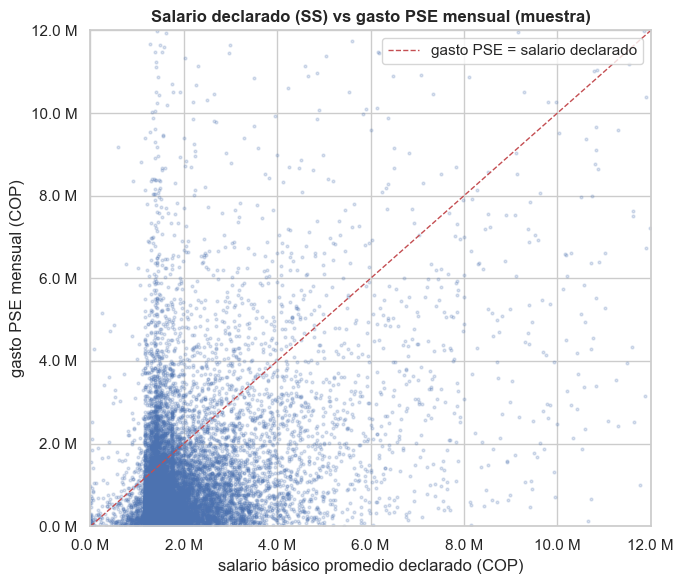

In [36]:
salario_persona = (ss.groupby("Número de documento")["Promedio salario básico"]
                   .first().pipe(num).rename("salario_declarado"))
gasto_pm = pse_num.groupby(["Número documento", "Periodo"])["valor"].sum()
gasto_persona = gasto_pm.groupby(level=0).mean().rename("gasto_pse_mensual")

tri = pd.concat([salario_persona, gasto_persona], axis=1, join="inner")
tri = tri[(tri > 0).all(axis=1)]
ratio = tri["gasto_pse_mensual"] / tri["salario_declarado"]
print(f"Personas comparables (salario declarado > 0 y gasto PSE > 0): {len(tri):,}")
print(f"Mediana del ratio gasto PSE / salario declarado: {ratio.median():.2f}")
print(f"Personas cuyo gasto PSE mensual SUPERA su salario declarado: {(ratio > 1).mean():.1%}")

fig, ax = plt.subplots(figsize=(7, 6))
m = tri.sample(min(30_000, len(tri)), random_state=42)
ax.scatter(m["salario_declarado"], m["gasto_pse_mensual"], s=4, alpha=.2)
lim = 12e6
ax.plot([0, lim], [0, lim], "r--", lw=1, label="gasto PSE = salario declarado")
ax.set(xlim=(0, lim), ylim=(0, lim), title="Salario declarado (SS) vs gasto PSE mensual (muestra)",
       xlabel="salario básico promedio declarado (COP)", ylabel="gasto PSE mensual (COP)")
ax.xaxis.set_major_formatter(fmt_mill); ax.yaxis.set_major_formatter(fmt_mill)
ax.legend(); plt.tight_layout(); plt.show()

---
## 8 · Conclusiones del EDA

### 8.1 · Sobre la estructura de los datos
1. **Granularidad mixta:** los tres datasets mezclan columnas de *resumen por persona* (promedios históricos
   repetidos en cada fila) con columnas de *detalle transaccional*. Para modelar hay que separar los dos niveles
   (tabla de personas + tabla de hechos) y no agregar los promedios como si fueran transacciones.
2. **Ventanas temporales distintas por fuente:** Seguridad Social cubre 2023-07 a 2026-06 (36 períodos),
   mientras Transferencias y PSE cubren 2025-01 a 2026-06 (18 períodos). La ventana común a las tres fuentes
   es 2025-01 → 2026-06; para features que crucen fuentes hay que alinear a ese rango.
3. **Cobertura asimétrica de personas:** el cruce del §7 dimensiona cuántas personas tienen visión 360°
   (las tres fuentes) — ese subconjunto es el mercado direccionable inmediato de los casos de uso 1–3.

### 8.2 · Sobre la calidad de los datos
1. **Ofuscación:** nombres, documentos y entidades enmascarados con `*`. El documento parcial funciona como
   cuasi-identificador (riesgo de colisión bajo, pero existe). Los nombres de comercios/entidades conservan
   prefijos útiles para categorizar.
2. **Truncamiento de Excel:** Transferencias y PSE traen exactamente el tope de filas de una hoja de Excel →
   los extractos están **cortados** y la historia de algunas personas queda incompleta. Pedir la fuente en
   CSV/Parquet o exportar por lotes.
3. **Ceros estructurales en SS:** IBC = 0 en subsistemas por los que no se cotiza (p. ej. pensionados que solo
   cotizan salud). No son valores faltantes: codifican el tipo de vinculación.
4. **Concentración en el SMLV** del salario básico: consistente con el mercado laboral colombiano y con la
   hipótesis del caso de uso 2 (IBC declarado ≪ capacidad real de gasto).

### 8.3 · Implicaciones para el modelado (CRISP-DM · Fases 3–4)
| Caso de uso | Insumo confirmado por el EDA |
|---|---|
| 1 · Monitoreo y alertas | Novedades PILA (§4.8) + series por período (§4.4, §5.5, §6.6) |
| 2 · Ingresos independientes | Triangulación IBC vs recibido vs gasto (§7.1) |
| 3 · Flujo de caja | Flujo neto por persona (§5.7) |
| 4 · Comportamientos de consumo | Taxonomía de comercios PSE (§6.4) |
| 5 · Análisis y segmentos | IBC × actividad económica × categoría de gasto (§4.7, §6.4) |

### 8.4 · Próximos pasos sugeridos
1. **Preparación de datos:** construir una tabla maestra *persona × mes* con features de las tres fuentes
   (IBC, días cotizados, novedades, recibido/enviado ACH-Transfiya, gasto PSE por categoría).
2. **Resolver el truncamiento** de los extractos con el dueño de los datos.
3. **Diccionario de datos formal** con reglas de negocio por campo (p. ej. semántica exacta de cada novedad PILA
   y de `Tipo planilla`).
4. **Prototipar el caso de uso 2** (estimador de ingresos): es 100 % operable con estos tres datasets y el EDA
   confirma la señal.